## 1. Importing Needed Libraries

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from skimage.feature import hog

## 2. Data Loading
Loading def_front and ok_front images, converting to grayscale.

In [2]:
X = [] 
y = []

for filename in os.listdir('data/casting_512x512/def_front'):
    img = cv2.imread(os.path.join('data/casting_512x512/def_front', filename), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128, 128))
    features = hog(img, pixels_per_cell=(16,16), cells_per_block=(2,2))
    X.append(features)
    y.append(1) # 1 = deffective

for filename in os.listdir('data/casting_512x512/ok_front'):
    img = cv2.imread(os.path.join('data/casting_512x512/ok_front', filename), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128, 128))
    features = hog(img, pixels_per_cell=(16,16), cells_per_block=(2,2))
    X.append(features)
    y.append(0) # 0 = not deffective

X = np.array(X)
y = np.array(y)

## 3. Data Overview
Class counts (defective vs non-defective) and a sample image check.

1. Number of non-deffective images: 519
__________________________________________________
2. Number of deffective images: 781
__________________________________________________
3. Shape and data tpye of images: ((128, 128), <class 'numpy.ndarray'>)
__________________________________________________
4. Example of image (non-defective)


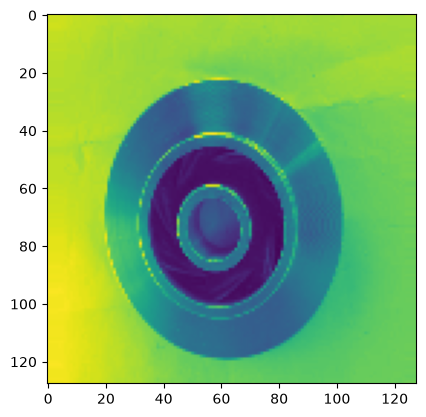

In [3]:
num_ok = len(os.listdir('data/casting_512x512/ok_front'))
num_def = len(os.listdir('data/casting_512x512/def_front'))

print(f"1. Number of non-deffective images: {num_ok}")
print(f"{'_'*50}")
print(f"2. Number of deffective images: {num_def}")
print(f"{'_'*50}")
print(f'3. Shape and data tpye of images: {img.shape, type(img)}')
print(f"{'_'*50}")
print(f'4. Example of image (non-defective)')
plt.imshow(img)
plt.savefig('results/non-defective_image.png', dpi=200, bbox_inches='tight')

## 4. Class Balance
Bar chart comparing defective vs non-defective image counts.

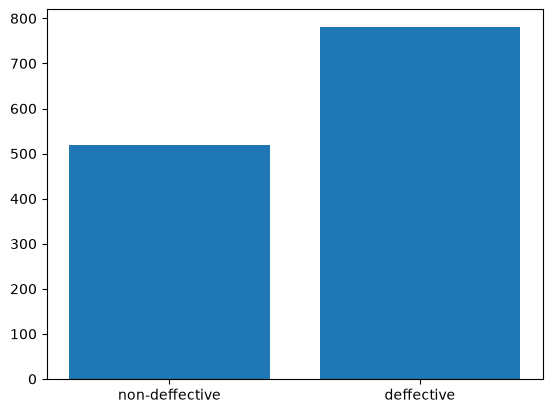

In [4]:
labels = ['non-deffective', 'deffective']
counts = [num_ok, num_def]
plt.bar(labels, counts)
plt.savefig('results/comparison.png', dpi=200, bbox_inches='tight')

## 5. Train/Test Split + Model Pipeline
Stratified 80/20 split, scaler + logistic regression pipeline, GridSearchCV tuning C via 10-fold CV.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression( C = 1e-3, solver = 'liblinear', max_iter = 1000, random_state = 42))
])

param_grid = {'model__C': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]}
grid = GridSearchCV(pipe, param_grid, cv=10, scoring = 'f1')

## 6. Model Training

In [6]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [1e-05, 0.0001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting,

## 7. Evaluation
Test accuracy, classification report, and best regularization parameter.

In [7]:
predictions = grid.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f'Model Accuracy: {accuracy * 100:.2f}%')
print(f"{'_'*50}")
print(f'Detailed Classification Report:')
print(classification_report(y_test, predictions, target_names=['non-deffective', 'deffective']))
print(f"{'_'*50}")
print(f'Best parameter for Regularization C: {grid.best_params_['model__C']}')
print(f'Best F1 score for Regularization that C: {grid.best_score_ * 100:.2f}%')

Model Accuracy: 91.54%
__________________________________________________
Detailed Classification Report:
                precision    recall  f1-score   support

non-deffective       0.87      0.92      0.90       104
    deffective       0.95      0.91      0.93       156

      accuracy                           0.92       260
     macro avg       0.91      0.92      0.91       260
  weighted avg       0.92      0.92      0.92       260

__________________________________________________
Best parameter for Regularization C: 0.1
Best F1 score for Regularization that C: 93.46%


## 8. Confusion Matrix

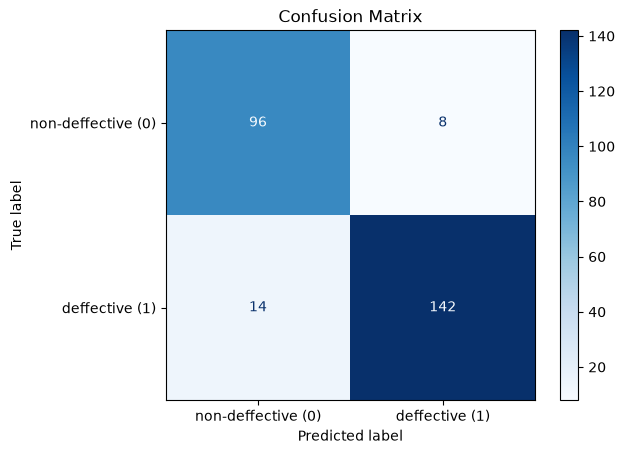

In [ ]:
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['non-deffective (0)', 'deffective (1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('results/confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()